In [1]:
from typing import Dict, TypedDict, List, Union, Annotated, Sequence
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, ToolMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool

load_dotenv()


c:\Users\ka448\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


True

In [2]:
@tool
def add(a: int, b: int):
    """Addition tool that adds two numbers together."""
    print(f"Adding {a} and {b}")
    return a + b
tools = [add]

llm = ChatOpenAI(model="gpt-5.4-nano").bind_tools(tools)

In [3]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [4]:
def agent_node(state: AgentState) -> AgentState:

    system_prompt = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")
    response = llm.invoke([system_prompt] + state["messages"])
    print(f"LLM response: {response} agent_node")
    return {"messages": [response]}

In [5]:
def decider(state: AgentState):
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and last.tool_calls:
        return "Continue"
    print("No tool calls, ending.")
    return "END"
def tool_node(state: AgentState) -> AgentState:
    response = llm.invoke(state["messages"])
    print(f"LLM response: {response} tool_node")
    return state

In [6]:
main_graph = StateGraph(AgentState)
main_graph.add_node("Agent", agent_node)
main_graph.add_node("Tool", ToolNode(tools))  

main_graph.set_entry_point("Agent")
main_graph.add_conditional_edges("Agent", decider, {"END": END, "Continue": "Tool"})
main_graph.add_edge("Tool", "Agent")  

x = main_graph.compile()

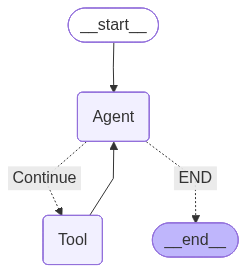

In [7]:
x

In [9]:
result = x.invoke({"messages": [HumanMessage(content="Hi")]})

LLM response: content='Hi! How can I help you today?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 146, 'total_tokens': 158, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOIsuH9jaRPUHfVn4tvhlu7TX0xkL', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019d3375-8f69-7070-a249-742de4cb286c-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 146, 'output_tokens': 12, 'total_tokens': 158, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}} agent_node
No tool calls, ending.


In [9]:
result

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='5a632c34-3f2d-4673-9d4a-0cb125006b87'),
  AIMessage(content='Hi! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 146, 'total_tokens': 158, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOHKnDLJP5kdqaFutRmAwNRdPUmb4', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d331a-a0fa-7db0-98f2-2fc6fcd63e31-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 146, 'output_tokens': 12, 'total_tokens': 158, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio'